In [68]:
import pandas as pd
import numpy as np

## **Fatching Data**

In [69]:
data = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
data.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

## **Data Exploration**

In [70]:
print(data.head())
print(data.info())
print(data.describe())  
print(data.isnull().sum())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null    

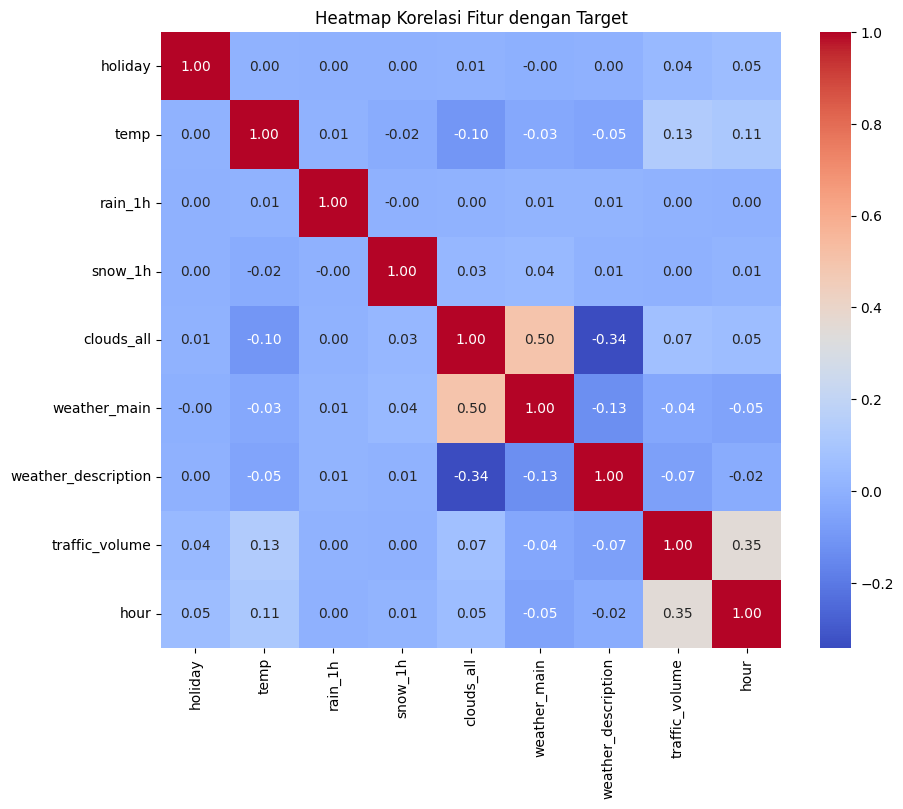

Korelasi tiap fitur dengan 'traffic_volume':
traffic_volume         1.000000
hour                   0.352401
temp                   0.130299
clouds_all             0.067054
holiday                0.038057
rain_1h                0.004714
snow_1h                0.000733
weather_main          -0.040151
weather_description   -0.067507
Name: traffic_volume, dtype: float64


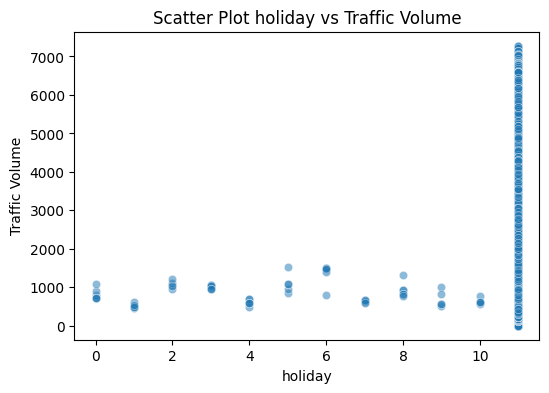

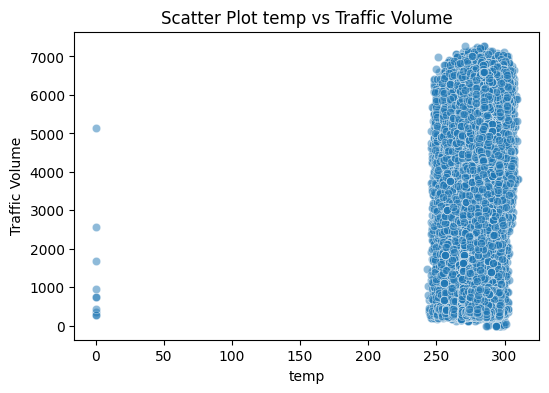

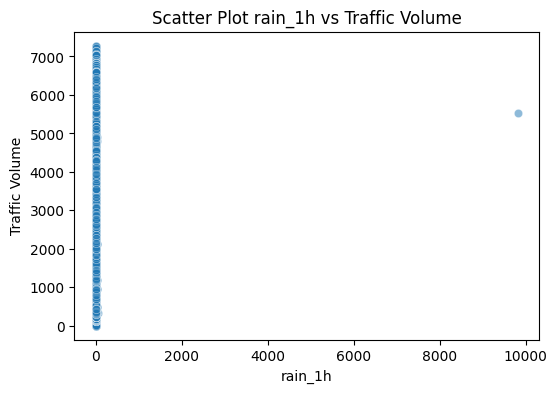

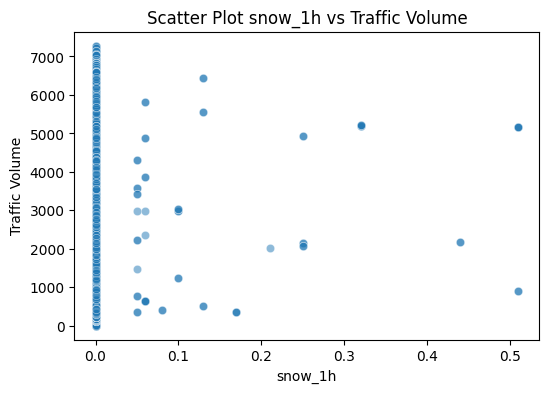

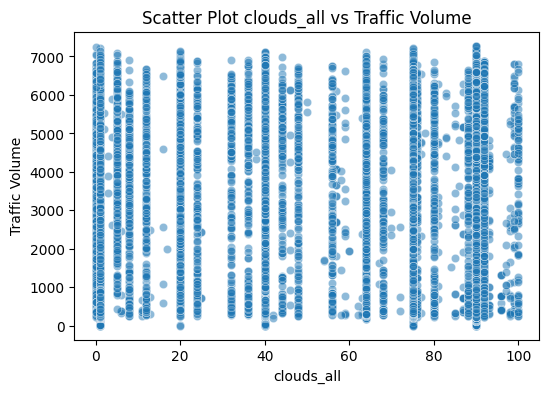

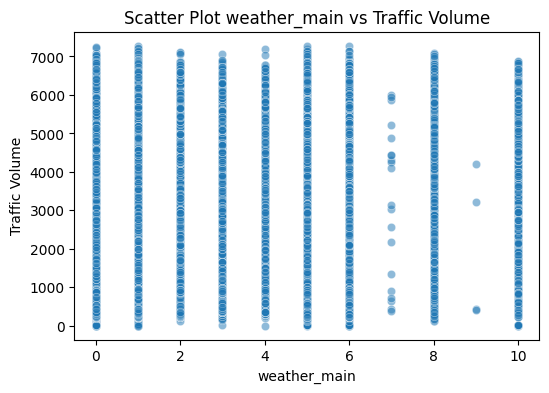

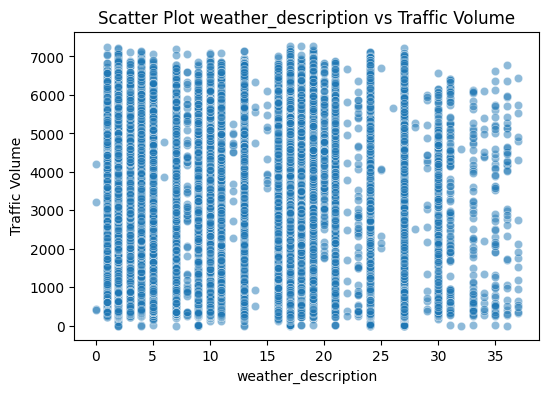

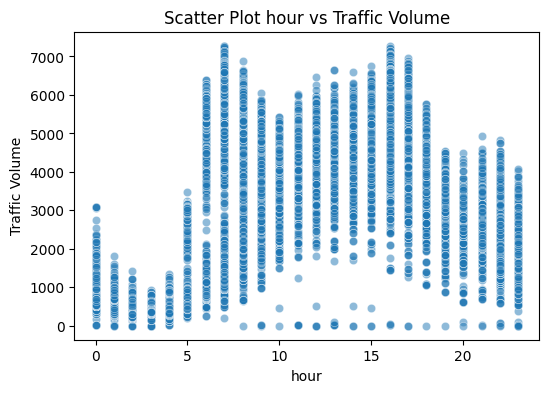

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

data_encoded = data.copy()
data_encoded['date_time'] = pd.to_datetime(data_encoded['date_time'])
data_encoded['hour'] = data_encoded['date_time'].dt.hour
data_encoded = data_encoded.drop(columns=['date_time'])

categorical_columns = ['holiday', 'weather_main', 'weather_description']
label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
    label_encoders[col] = le  

correlation_matrix = data_encoded.corr()
correlation_with_target = correlation_matrix['traffic_volume'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('Heatmap Korelasi Fitur dengan Target')
plt.show()

print("Korelasi tiap fitur dengan 'traffic_volume':")
print(correlation_with_target)

features = [col for col in data_encoded.columns if col != 'traffic_volume']
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=data_encoded[feature], y=data_encoded['traffic_volume'], alpha=0.5)
    plt.title(f'Scatter Plot {feature} vs Traffic Volume')
    plt.xlabel(feature)
    plt.ylabel('Traffic Volume')
    plt.show()


## **Handling Noice**

In [72]:
import numpy as np
import pandas as pd

# Menentukan rentang wajar untuk setiap kolom
valid_ranges = {
    'temp': (200, 350),  
    'rain_1h': (0, 500), 
    'snow_1h': (0, 500),  
    'clouds_all': (0, 100), 
    'traffic_volume': (0, 100000),  
}

def replace_with_median(data, valid_ranges):
    for col, (min_val, max_val) in valid_ranges.items():
        # Hitung median hanya untuk nilai yang wajar
        valid_median = data[(data[col] >= min_val) & (data[col] <= max_val)][col].median()
        
        # Ganti nilai yang tidak wajar dengan median
        data[col] = data[col].apply(lambda x: valid_median if not (min_val <= x <= max_val) else x)
    return data

# Mengganti nilai tidak wajar dengan median
data_cleaned = replace_with_median(data.copy(), valid_ranges)

# Menampilkan data setelah penggantian
print("Data setelah mengganti nilai tidak wajar dengan median:")
print(data_cleaned)


Data setelah mengganti nilai tidak wajar dengan median:
      holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
0         NaN  288.28      0.0      0.0          40        Clouds   
1         NaN  289.36      0.0      0.0          75        Clouds   
2         NaN  289.58      0.0      0.0          90        Clouds   
3         NaN  290.13      0.0      0.0          90        Clouds   
4         NaN  291.14      0.0      0.0          75        Clouds   
...       ...     ...      ...      ...         ...           ...   
48199     NaN  283.45      0.0      0.0          75        Clouds   
48200     NaN  282.76      0.0      0.0          90        Clouds   
48201     NaN  282.73      0.0      0.0          90  Thunderstorm   
48202     NaN  282.09      0.0      0.0          90        Clouds   
48203     NaN  282.12      0.0      0.0          90        Clouds   

          weather_description            date_time  traffic_volume  
0            scattered clouds  2012-10-02 09:0

In [73]:

print(data_cleaned[['weather_main', 'holiday', 'weather_description']].value_counts())
data_cleaned[['weather_main', 'holiday', 'weather_description']] = data_cleaned[['weather_main', 'holiday', 'weather_description']].apply(lambda x: x.str.strip().str.lower())
print(data_cleaned[['weather_main', 'holiday', 'weather_description']].nunique())


weather_main  holiday                    weather_description   
Clear         Independence Day           sky is clear              4
              State Fair                 sky is clear              3
Mist          Thanksgiving Day           mist                      3
Clear         Veterans Day               sky is clear              3
Clouds        Veterans Day               broken clouds             2
Haze          Martin Luther King Jr Day  haze                      2
Clouds        Washingtons Birthday       few clouds                2
Clear         Columbus Day               Sky is Clear              2
Mist          Martin Luther King Jr Day  mist                      2
Clouds        Memorial Day               scattered clouds          2
Rain          Christmas Day              light rain                2
Snow          New Years Day              light snow                2
Clear         Columbus Day               sky is clear              2
Rain          Labor Day                

## **Checking & Handling Missing Value**

In [74]:
print(data_cleaned.isnull().sum())

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


In [75]:
data_cleaned['rain_1h'] = data_cleaned['rain_1h'].replace(',', '.', regex=True).astype(float)
data_cleaned['snow_1h'] = data_cleaned['snow_1h'].replace(',', '.', regex=True).astype(float)

## **Handling Outlier**

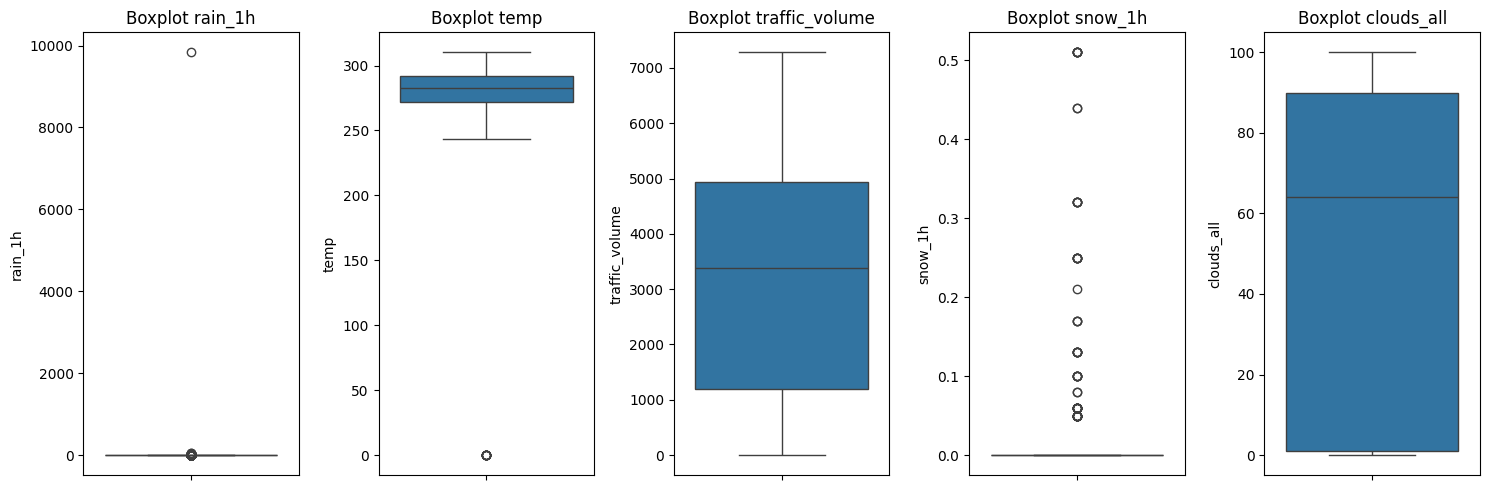

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ["rain_1h", "temp", "traffic_volume", "snow_1h", "clouds_all"]

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_columns):
    plt.subplot(1, len(numerical_columns), i + 1)
    sns.boxplot(data=data, y=col)
    plt.title(f"Boxplot {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [77]:
Q1 = data_cleaned["temp"].quantile(0.25)
Q3 = data_cleaned["temp"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

valid_min = data_cleaned[(data_cleaned["temp"] >= lower_bound) & (data_cleaned["temp"] <= upper_bound)]["temp"].min()
valid_max = data_cleaned[(data_cleaned["temp"] >= lower_bound) & (data_cleaned["temp"] <= upper_bound)]["temp"].max()

data_cleaned["temp"] = data_cleaned["temp"].apply(
    lambda x: valid_min if x < lower_bound else (valid_max if x > upper_bound else x)
)

print(f"Jumlah outlier setelah penanganan: {(data_cleaned['temp'] < lower_bound).sum() + (data_cleaned['temp'] > upper_bound).sum()}")
print(f"Data setelah mengganti outlier dengan nilai min/max: {data_cleaned.shape}")


Jumlah outlier setelah penanganan: 0
Data setelah mengganti outlier dengan nilai min/max: (48204, 9)


In [78]:
# Simpan dataset bersih ke file baru
data_cleaned.to_csv("data_siap_median.csv", index=False)


## **Train Test Split**

In [79]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Baca dataset
data = pd.read_csv("data_siap_median.csv")

data['date_time'] = pd.to_datetime(data['date_time'])
data = data.sort_values(by='date_time')

data['hour'] = data['date_time'].dt.hour

data['holiday'] = data['holiday'].fillna('none')
data['holiday'] = data['holiday'].replace('none', 'not_holiday')
le = LabelEncoder()
data['holiday'] = le.fit_transform(data['holiday'])

features = ['temp', 'clouds_all', 'hour', 'snow_1h', 'holiday', 'rain_1h']
target = 'traffic_volume'

scaler = MinMaxScaler()
data[features + [target]] = scaler.fit_transform(data[features + [target]])

# Pisahkan data menjadi fitur (X) dan target (y)
X = data[features].values
y = data[target].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **MODELLING**

## **Random Forest**

In [80]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [81]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [82]:
y_pred_rf = model_rf.predict(X_test)

# Menghitung MSE dan RMSE
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_rf)

# Menghitung R-squared
r2 = r2_score(y_test, y_pred_rf)

# Menampilkan hasil evaluasi
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 0.016080616034805678
Root Mean Squared Error (RMSE): 0.12680936887630062
Mean Absolute Error (MAE): 0.07611431335225338
R-squared (R2): 0.7844330345342119


## **SVM**

In [83]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [84]:
model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1) #'rbf', linear' atau 'poly'
model_svr.fit(X_train, y_train)

SVR()

In [85]:
y_pred_svr = model_svr.predict(X_test)

# Menghitung MSE dan RMSE
mse = mean_squared_error(y_test, y_pred_svr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_svr)

# Menghitung R-squared
r2 = r2_score(y_test, y_pred_svr)

# Menampilkan hasil evaluasi
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 0.02333536905078954
Root Mean Squared Error (RMSE): 0.15275918646938894
Mean Absolute Error (MAE): 0.11246959328745197
R-squared (R2): 0.687180224724285


## **KNN**

In [86]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
knn_model = KNeighborsRegressor(n_neighbors=5) 
knn_model.fit(X_train, y_train)

KNeighborsRegressor()

In [87]:
y_knn_pred = knn_model.predict(X_test)

# Menghitung MSE, RMSE, MAE, dan R-squared
mse_knn = mean_squared_error(y_test, y_knn_pred)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test, y_knn_pred)
r2_knn = r2_score(y_test, y_knn_pred)

# Menampilkan hasil evaluasi
print(f"KNN - Mean Squared Error (MSE): {mse_knn}")
print(f"KNN - Root Mean Squared Error (RMSE): {rmse_knn}")
print(f"KNN - Mean Absolute Error (MAE): {mae_knn}")
print(f"KNN - R-squared (R2): {r2_knn}")



KNN - Mean Squared Error (MSE): 0.01794548006504706
KNN - Root Mean Squared Error (RMSE): 0.13396074076029538
KNN - Mean Absolute Error (MAE): 0.08562315420291773
KNN - R-squared (R2): 0.759433800727788


## **Train Test Split 2**

In [88]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

data = pd.read_csv("data_siap_median.csv")
data['date_time'] = pd.to_datetime(data['date_time'])
data = data.sort_values(by='date_time')
data['hour'] = data['date_time'].dt.hour

data['holiday'] = data['holiday'].fillna('none')
data['holiday'] = data['holiday'].replace('none', 'not_holiday')
le = LabelEncoder()
data['holiday'] = le.fit_transform(data['holiday'])

le_weather_main = LabelEncoder()
data['weather_main'] = le_weather_main.fit_transform(data['weather_main'].fillna('none'))  

le_weather_description = LabelEncoder()
data['weather_description'] = le_weather_description.fit_transform(data['weather_description'].fillna('none'))  

features = ['temp', 'clouds_all', 'hour', 'snow_1h', 'holiday', 'rain_1h', 'weather_main', 'weather_description']
target = 'traffic_volume'

scaler = MinMaxScaler()
data[features + [target]] = scaler.fit_transform(data[features + [target]])

X = data[features].values
y = data[target].values

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y, test_size=0.2, random_state=42)



## **Random Forest**

In [89]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_2, y_train_2)

RandomForestRegressor(random_state=42)

In [90]:
y_pred_rf_2 = model_rf.predict(X_test_2)

# Menghitung MSE dan RMSE
mse = mean_squared_error(y_test_2, y_pred_rf_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_2, y_pred_rf_2)

# Menghitung R-squared
r2 = r2_score(y_test_2, y_pred_rf_2)

# Menampilkan hasil evaluasi
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 0.016946685029486583
Root Mean Squared Error (RMSE): 0.1301794339728307
Mean Absolute Error (MAE): 0.08305658443785573
R-squared (R2): 0.7728230399504673


## **SVM**

In [91]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [92]:
model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1) #'rbf', linear' atau 'poly'
model_svr.fit(X_train_2, y_train_2)

SVR()

In [93]:
y_pred_svr_2 = model_svr.predict(X_test_2)

# Menghitung MSE dan RMSE
mse = mean_squared_error(y_test_2, y_pred_svr_2)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_2, y_pred_svr_2)

# Menghitung R-squared
r2 = r2_score(y_test_2, y_pred_svr_2)

# Menampilkan hasil evaluasi
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 0.023334323902397435
Root Mean Squared Error (RMSE): 0.15275576552915257
Mean Absolute Error (MAE): 0.11281089443730428
R-squared (R2): 0.6871942353484339


## **KNN**

In [94]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [95]:
knn_model = KNeighborsRegressor(n_neighbors=5) 
knn_model.fit(X_train_2, y_train_2)

KNeighborsRegressor()

In [96]:
y_knn_pred_2 = knn_model.predict(X_test_2)

# Menghitung MSE, RMSE, MAE, dan R-squared
mse_knn = mean_squared_error(y_test_2, y_knn_pred_2)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test_2, y_knn_pred_2)
r2_knn = r2_score(y_test_2, y_knn_pred_2)

# Menampilkan hasil evaluasi
print(f"KNN - Mean Squared Error (MSE): {mse_knn}")
print(f"KNN - Root Mean Squared Error (RMSE): {rmse_knn}")
print(f"KNN - Mean Absolute Error (MAE): {mae_knn}")
print(f"KNN - R-squared (R2): {r2_knn}")



KNN - Mean Squared Error (MSE): 0.019233547074158024
KNN - Root Mean Squared Error (RMSE): 0.13868506435142186
KNN - Mean Absolute Error (MAE): 0.09086555986281117
KNN - R-squared (R2): 0.7421667572345754


In [97]:
y_knn_pred_2 = knn_model.predict(X_test_2)

# Menghitung MSE, RMSE, MAE, dan R-squared
mse_knn = mean_squared_error(y_test_2, y_knn_pred_2)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test_2, y_knn_pred_2)
r2_knn = r2_score(y_test_2, y_knn_pred_2)

# Menampilkan hasil evaluasi
print(f"KNN - Mean Squared Error (MSE): {mse_knn}")
print(f"KNN - Root Mean Squared Error (RMSE): {rmse_knn}")
print(f"KNN - Mean Absolute Error (MAE): {mae_knn}")
print(f"KNN - R-squared (R2): {r2_knn}")



KNN - Mean Squared Error (MSE): 0.019233547074158024
KNN - Root Mean Squared Error (RMSE): 0.13868506435142186
KNN - Mean Absolute Error (MAE): 0.09086555986281117
KNN - R-squared (R2): 0.7421667572345754


## **Train Test Split 3**

In [98]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Baca dataset
data = pd.read_csv("data_siap_median.csv")

data['date_time'] = pd.to_datetime(data['date_time'])
data = data.sort_values(by='date_time')

data['hour'] = data['date_time'].dt.hour

data['holiday'] = data['holiday'].fillna('none')
data['holiday'] = data['holiday'].replace('none', 'not_holiday')
le = LabelEncoder()
data['holiday'] = le.fit_transform(data['holiday'])

features = ['temp', 'clouds_all', 'hour', 'snow_1h', 'holiday', 'rain_1h']
target = 'traffic_volume'

# Pisahkan data menjadi fitur (X) dan target (y)
X = data[features].values
y = data[target].values

# Train-test split
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X, y, test_size=0.2, random_state=42)


## **Random Forest**

In [99]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_3, y_train_3)

RandomForestRegressor(random_state=42)

In [100]:
y_pred_rf_3 = model_rf.predict(X_test_3)

# Menghitung MSE dan RMSE
mse = mean_squared_error(y_test_3, y_pred_rf_3)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_3, y_pred_rf_3)

# Menghitung R-squared
r2 = r2_score(y_test_3, y_pred_rf_3)

# Menampilkan hasil evaluasi
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 853382.9344408461
Root Mean Squared Error (RMSE): 923.787277700254
Mean Absolute Error (MAE): 554.4887741822629
R-squared (R2): 0.7841456917529556


## **SVM**

In [101]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

In [102]:
model_svr = SVR(kernel='rbf', C=1.0, epsilon=0.1) #'rbf', linear' atau 'poly'
model_svr.fit(X_train_3, y_train_3)

SVR()

In [103]:
y_pred_svr_3 = model_svr.predict(X_test_3)

# Menghitung MSE dan RMSE
mse = mean_squared_error(y_test_3, y_pred_svr_3)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_3, y_pred_svr_3)

# Menghitung R-squared
r2 = r2_score(y_test_3, y_pred_svr_3)

# Menampilkan hasil evaluasi
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R2): {r2}")


Mean Squared Error (MSE): 3917661.7605994996
Root Mean Squared Error (RMSE): 1979.308404620033
Mean Absolute Error (MAE): 1735.3679882084482
R-squared (R2): 0.009068338313811597


## **KNN**

In [104]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [105]:
knn_model = KNeighborsRegressor(n_neighbors=5) 
knn_model.fit(X_train_3, y_train_3)

KNeighborsRegressor()

In [106]:
y_knn_pred_3 = knn_model.predict(X_test_3)

# Menghitung MSE, RMSE, MAE, dan R-squared
mse_knn = mean_squared_error(y_test_3, y_knn_pred_3)
rmse_knn = np.sqrt(mse_knn)
mae_knn = mean_absolute_error(y_test_3, y_knn_pred_3)
r2_knn = r2_score(y_test_3, y_knn_pred_3)

# Menampilkan hasil evaluasi
print(f"KNN - Mean Squared Error (MSE): {mse_knn}")
print(f"KNN - Root Mean Squared Error (RMSE): {rmse_knn}")
print(f"KNN - Mean Absolute Error (MAE): {mae_knn}")
print(f"KNN - R-squared (R2): {r2_knn}")



KNN - Mean Squared Error (MSE): 955074.4327185977
KNN - Root Mean Squared Error (RMSE): 977.279096634425
KNN - Mean Absolute Error (MAE): 629.3970749922207
KNN - R-squared (R2): 0.7584238884106704


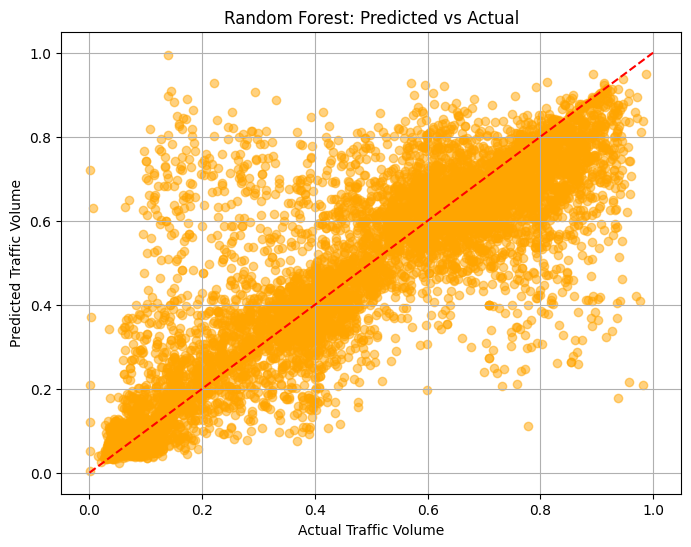

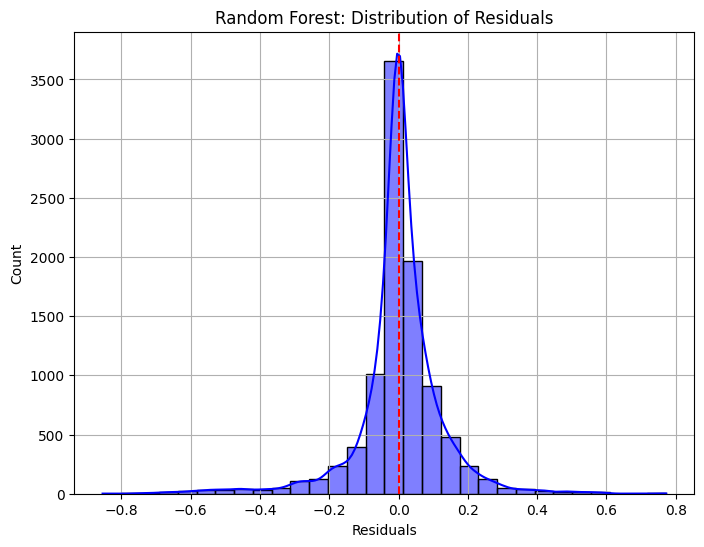

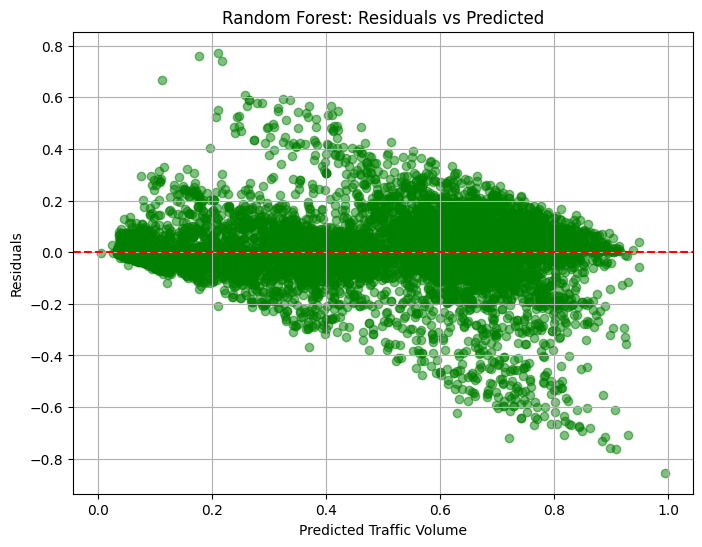

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Predicted vs. Actual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='orange')
plt.plot([0, 1], [0, 1], '--r')  # Garis diagonal ideal
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Random Forest: Predicted vs Actual")
plt.grid()
plt.show()

# 2. Residual Plot
residuals_rf = y_test - y_pred_rf
plt.figure(figsize=(8, 6))
sns.histplot(residuals_rf, kde=True, bins=30, color='blue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals")
plt.title("Random Forest: Distribution of Residuals")
plt.grid()
plt.show()

# 3. Residuals vs Predicted Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.5, color='green')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title("Random Forest: Residuals vs Predicted")
plt.grid()
plt.show()
